This dataset have some passenger datas in a British passenger liner named RMS Titanic which sank sank in the North Atlantic Ocean on 15 April 1912 after striking an iceberg during her maiden voyage from Southampton, UK, to New York City. Of the estimated 2,224 passengers and crew aboard, more than 1,500 died, which made the sinking possibly one of the deadliest for a single ship up to that time. 

It remains to this day the deadliest peacetime sinking of a superliner or cruise ship. The disaster drew much public attention, provided foundational material for the disaster film genre, and has inspired many artistic works.

> Source: https://en.wikipedia.org/wiki/Titanic

We are going to examine some passenger datas in the disaster and use some Machine Learning classification models to predict whether they survived or not by inputing their some datas.

Lets start by importing some libraries to examine the dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from warnings import filterwarnings
filterwarnings("ignore")

%matplotlib inline

#Loading and Understanding the Data

We need to download the dataset from seaborn

In [ ]:
titanic_data = sns.load_dataset("titanic")

Lets look at the first 5 rows in the dataset

In [ ]:
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Variables and their types in the dataset are described below:
 
* Categorical/Nominal: Variables that can be divided into multiple categories but having no order or priority. Nominal categorical feature in the dataset is Embarked. There are names of port of embarkation in "embarked" feature; 
1. C = Cherbourg Port,
2. Q = Queenstown Port,
3. S = Southampton Port
* Binary: A subtype of categorical features, where the variable has only two categories. Binary feature in the dataset is Sex. There are sex types of passengers (Male and Female) in "sex" feature
* Ordinal: They are similar to categorical features but they have an order. Ordinal feature in the dataset is Pclass. There are passenger classes as 1, 2 and 3 in "pclass" feature.
* Numerical: They can take up any value between the minimum and maximum values in a column. Numerical features in the dataset are Age and Fare. There are informations about ages of passengers in "age" feature and fare of passengers in "fare" feature. 
* Count: They represent the count of a variable. Count features in the dataset are SibSp and Parch. SibSp gives information about total number of siblings and spouses of passengers aboard. Parch gives information about total number of parents and children of passengers aboard.
* **Target: Target feature is the main variable in the dataset which will be predicted in ML models. Target variable (aka dependent variable) in the dataset is Survived. There are two categorical observations in "survived" variable which 1 if passenger survived and 0 if passenger died**

>
There are some columns which are duplicated from some columns or have hundreads of missing values. This columns will be removed from the dataset;
1. class (same with pclass)
2. who (same with sex)
3. adult_male (indicating whether male is adult or not)
4. deck (has 688 missing walues)
5. embark_town (same with embarked)
6. alive (same with survived)
7. alone (True if sum of sibsp and parchs is 0, else False)


In [ ]:
titanic_data.drop(titanic_data.columns[8:], axis=1, inplace=True)

We removed all columns we mentioned above. Take a look at the first 5 rows of the dataset one more time

In [ ]:
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


It looks better now.

The dataset will be split into train dataset which we will observe it's variables and train it on ML models, and test dataset which we will test the model's performances. 
> 
However, we have to be careful about spliting. We should not split the dataset randomly by importing train_test_split() in this process. The split should represent all passenger datas to generalize the results of ML models. Which is why we need to import StratifiedShuffleSplit from sklearn.model_selection. 
>
However, the main problem is which feature we will use to generalize. We are examining passenger data. 'Sex' feature is so important in regards to representing the passenger datas. We, therefore, will split with equal rate the dataset into train dataset and test dataset based on sex feature.



In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

sss=StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_indices, test_indices in sss.split(titanic_data, titanic_data["sex"]):
  train_data=titanic_data.iloc[train_indices]
  test_data=titanic_data.iloc[test_indices]

print("train_data.shape:", train_data.shape)
print("test_data.shape: ", test_data.shape)

train_data.shape: (712, 8)
test_data.shape:  (179, 8)


We have split the dataset into train dataset and test dataset at the rate of 20%. Both has male and female observations of sex feature at equal rate. Lets see the result

In [ ]:
print("For Train Dataset:")
print(train_data.sex.value_counts())
print("*"*32)
print("For Test Dataset:")
print(test_data.sex.value_counts())

For Train Dataset:
male      461
female    251
Name: sex, dtype: int64
********************************
For Test Dataset:
male      116
female     63
Name: sex, dtype: int64


> Consider that we won't touch test dataset till training ML models with train dataset. That is to say we will pretend there is no test dataset

Lets now see numerical description of the variables of the train dataset

In [ ]:
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,712.0,0.389045,0.487876,0.00,0.0000,0.00000,1.000,1.0000
pclass,712.0,2.323034,0.838341,1.00,2.0000,3.00000,3.000,3.0000
age,578.0,29.781436,14.628503,0.42,21.0000,28.00000,38.000,80.0000
sibsp,712.0,0.546348,1.110283,0.00,0.0000,0.00000,1.000,8.0000
parch,712.0,0.373596,0.803144,0.00,0.0000,0.00000,0.000,6.0000
fare,712.0,31.282893,44.377233,0.00,7.8958,14.45625,31.275,512.3292


We can observe in the table above those:

* count, mean, standart deviation, minimum %25, median (%50), %75 and maximum value of each variables which have numerical observation.
* outlier value situation of each features. For example, if there big difference between %25 value and minimum value or %75 value and maximun value of a feature like "age", we may make interpretation there is some outlier value.
* missing value by looking at the count column 

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 788 to 261
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  712 non-null    int64  
 1   pclass    712 non-null    int64  
 2   sex       712 non-null    object 
 3   age       578 non-null    float64
 4   sibsp     712 non-null    int64  
 5   parch     712 non-null    int64  
 6   fare      712 non-null    float64
 7   embarked  710 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 50.1+ KB


Types of the variables are given above. According to that:
* float64 (2): "age" and "fare"
* int64 (4): "survived", "pclass", "sibsp" and "parch"
* categorical (2): "sex" and "embarked"

We will now explore the train dataset by using some visualization types

#Exploratory Data Analysis

We will use several visualizaton types to understand the dataset. We, however, should consider the types of the variables to visualize. For example, categorical variables are not usable for histogram, but continuous variables are. Also, continuous variables are not usable for countplot and barplot, but categorical variables are.
>
Briefly, Categorical/Nominal ("embarked"), Binary ("sex" and "survived" as target), Ordinal ("pclass") and Count ("sibsp" and "parch") variables should be visualized by countplot, barplot, catplot and FacetGrid to understand their observations. Continuous variables ("age" and "fare") shoud be visualized byhistogram, FacetGrid (with categorical features)
>
Firstly, let's start with the categorical variables.

## Categorical Features

***Pclass***

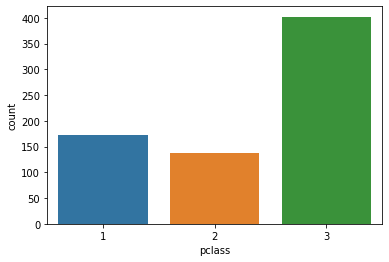

Pclass Distribution:
3    402
1    172
2    138
Name: pclass, dtype: int64


In [ ]:
sns.countplot(data=train_data, x='pclass')
plt.show()

print("Pclass Distribution:")
print(train_data.pclass.value_counts())

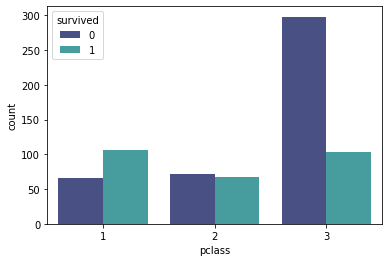

Survival possibility:
pclass           1         2         3
survived  0.616279  0.485507  0.258706
--------------------------------
Total number of SURVIVED in pclass
1         106
3         104
2          67
dtype: int64
--------------------------------
Total number of DEAD in pclass
3         298
2          71
1          66
dtype: int64


In [ ]:
sns.countplot(data=train_data, x='pclass', hue="survived", palette='mako')
plt.show()

pclass_surv= train_data[["pclass", "survived"]].groupby("pclass").mean()
print("Survival possibility:")
print(pclass_surv.T)
print("-"*32)
print("Total number of SURVIVED in", train_data[["pclass"]][train_data["survived"] == 1].value_counts())
print("-"*32)
print("Total number of DEAD in", train_data[["pclass"]][train_data["survived"] == 0].value_counts())

Pclass feature has ordinal observations which can be sorted from small to big: 1, 2, 3. There are differences among them as count and survival possibility survival.
* 402 passengers used third class. We are able to say that third class is more than half of all the classes. This class may be the cheapest (we will see later when the class is visualized with fare feature). To mention the survival possibility, a passenger who is in third class has about 26% chance to be alive (Survived: 104, Dead: 298).
* 172 passengers used first class. A passenger's survival possibility in this class is about 62% (Survived: 106, Dead: 66). That is a big possibility. Maybe, we can say that the most expensive class is first class.
* 138 passengers used second class. Survival possibility in this class is 49% (Survived: 67, Dead: 71). That means a passenger has half chance to be alive in second class

***Sex***

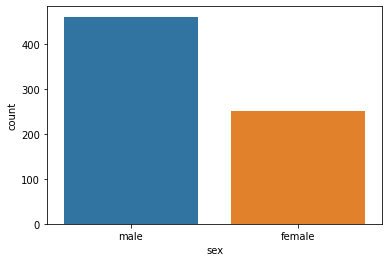

Sex Distribution:
male      461
female    251
Name: sex, dtype: int64


In [ ]:
sns.countplot(data=train_data, x='sex')
plt.show()

print("Sex Distribution:")
print(train_data.sex.value_counts())

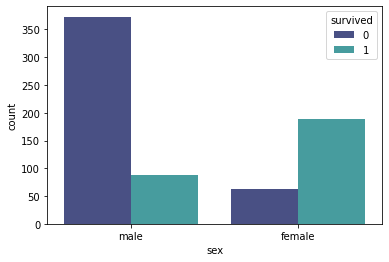

Survival possibility:
sex         female      male
survived  0.752988  0.190889
--------------------------------
Total number of SURVIVED in sex   
female    189
male       88
dtype: int64
--------------------------------
Total number of DEAD in sex   
male      373
female     62
dtype: int64


In [ ]:
sns.countplot(data=train_data, x='sex', hue="survived", palette='mako')
plt.show()

sex_surv=train_data[["sex", "survived"]].groupby("sex").mean()
print("Survival possibility:")
print(sex_surv.T)
print("-"*32)

print("Total number of SURVIVED in", train_data[["sex"]][train_data["survived"] == 1].value_counts())
print("-"*32)

print("Total number of DEAD in", train_data[["sex"]][train_data["survived"] == 0].value_counts())

Sex feature has binary observations which are composed of "male" and "female" and cannot be sorted. There are differences among them as count and the survival possibility.
* 461 passengers were male. Almost two thirds of passengers aboard were male. As survival possibility, a male passenger had 19% chance (Survived: 189, Dead: 373). That is a so bad rate.
* 251 passengers were female. A passenger's survival possibility in the ship who was female was about 75% (Survived: 189, Dead: 62). This is a perfect result. Females are always lucky

***SibSp***

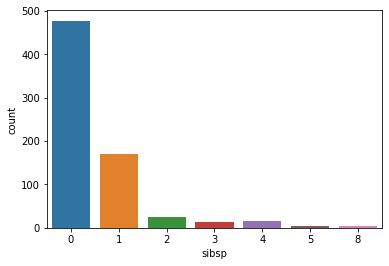

Sibsp Distribution:
0    477
1    171
2     25
4     16
3     13
8      5
5      5
Name: sibsp, dtype: int64
--------------------------------


In [ ]:
sns.countplot(data=train_data, x='sibsp')
plt.show()
train_data.sibsp.value_counts()

print("Sibsp Distribution:")
print(train_data.sibsp.value_counts())
print("-"*32)

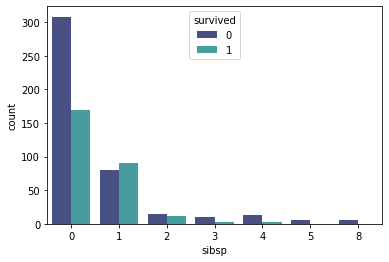

Survival possibility:
sibsp            0         1     2         3       4    5    8
survived  0.354298  0.532164  0.44  0.230769  0.1875  0.0  0.0
--------------------------------
Total number of SURVIVED in sibsp
0        169
1         91
2         11
3          3
4          3
dtype: int64
--------------------------------
Total number of DEAD in sibsp
0        308
1         80
2         14
4         13
3         10
5          5
8          5
dtype: int64


In [ ]:
sns.countplot(data=train_data, x='sibsp', hue="survived", palette='mako')
plt.show()

sibsp_surv= train_data[["sibsp", "survived"]].groupby("sibsp").mean()
print("Survival possibility:")
print(sibsp_surv.T)
print("-"*32)

print("Total number of SURVIVED in", train_data[["sibsp"]][train_data["survived"] == 1].value_counts())
print("-"*32)

print("Total number of DEAD in", train_data[["sibsp"]][train_data["survived"] == 0].value_counts())

SibSp feature is a count feature which shows total number of siblings and spouses of each passengers aboard. Which is why there is different between values and the values can be sorted as ordinal. 
* The most of passengers had no sibling and spouse. We, however, cannot say they were alone. They may have had parent and/or children.
* Those, who the sum of their siblings and spouses was only 1, had more lucky with the survival rate of 53% (Total number: 171 with 91 survived, 80 dead) comparing with others
* Those, who the sum of their siblings and spouses were more (like 5, 8) comparing with others, were less lucky. For example, no any survived in 5.

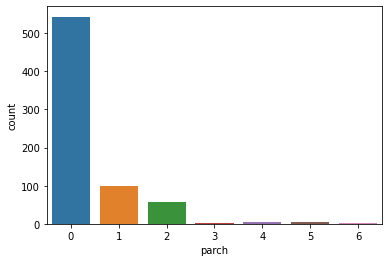

Parch Distribution:
0    543
1     99
2     58
5      4
4      4
3      3
6      1
Name: parch, dtype: int64


In [ ]:
sns.countplot(data=train_data, x='parch')
plt.show()
train_data.parch.value_counts()

print("Parch Distribution:")
print(train_data.parch.value_counts())

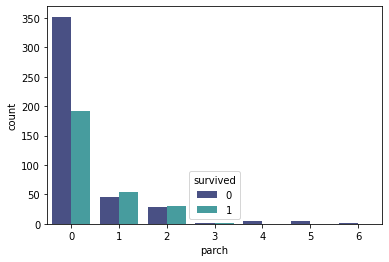

Survival possibility:
parch           0         1         2         3    4    5    6
survived  0.35175  0.545455  0.517241  0.666667  0.0  0.0  0.0
--------------------------------
Total number of SURVIVED in parch
0        191
1         54
2         30
3          2
dtype: int64
--------------------------------
Total number of DEAD in parch
0        352
1         45
2         28
4          4
5          4
3          1
6          1
dtype: int64


In [ ]:
sns.countplot(data=train_data, x='parch', hue="survived", palette='mako')
plt.show()

parch_surv= train_data[["parch", "survived"]].groupby("parch").mean()
print("Survival possibility:")
print(parch_surv.T)
print("-"*32)

print("Total number of SURVIVED in", train_data[["parch"]][train_data["survived"] == 1].value_counts())
print("-"*32)

print("Total number of DEAD in", train_data[["parch"]][train_data["survived"] == 0].value_counts())

Parch feature is a count feature just like SibSp. This feature shows total number of parents and children of each passengers aboard. The values can be sorted as ordinal.
* 543 passengers had no parent and children. To evaluate with SibSp values, many passengers were alone aboard.
Also we can say that those who had no parent and children aboard have %35 chance to be alive (Survived: 191, Dead:352). That is not a good result comparing with those who total number of their parents and children were 1 or 2 or 3
* The value which has the best survival possibility with the rate of 67% is 3. This is a really perfect rate but total numbers of those who have this value is 3. There is no sufficient passenger to generalize 
* Passengers, who had more, had no chance with the survival rate of 0%.

NOTE that we can understand from the values of SibSp and Parch features that a crowded family has less chance for survival comparing with a small family or an alone passenger

***Embarked Port***

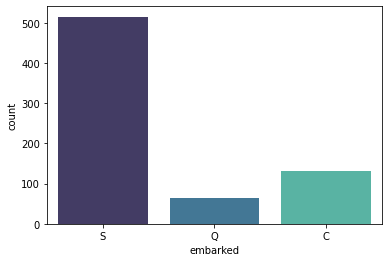

Embarked Distribution:
S    515
C    132
Q     63
Name: embarked, dtype: int64


In [ ]:
sns.countplot(data=train_data, x='embarked', palette='mako')
plt.show()
train_data.embarked.value_counts()

print("Embarked Distribution:")
print(train_data.embarked.value_counts())

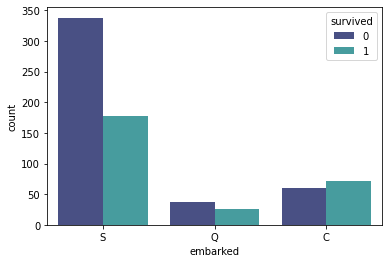

Survival possibility:
embarked         C         Q         S
survived  0.545455  0.412698  0.343689
--------------------------------
Total number of SURVIVED in embarked
S           177
C            72
Q            26
dtype: int64
--------------------------------
Total number of DEAD in embarked
S           338
C            60
Q            37
dtype: int64


In [ ]:
sns.countplot(data=train_data, x='embarked', hue="survived", palette='mako')
plt.show()

embarked_surv= train_data[["embarked", "survived"]].groupby("embarked").mean()
print("Survival possibility:")
print(embarked_surv.T)
print("-"*32)

print("Total number of SURVIVED in", train_data[["embarked"]][train_data["survived"] == 1].value_counts())
print("-"*32)

print("Total number of DEAD in", train_data[["embarked"]][train_data["survived"] == 0].value_counts())

* S:    515
* C:    132
* Q:     63

Embarked feature is a categorical feature and has nominal observations with C (Cherbourg Port), Q (Queenstown Port), S (Southampton Port) which cannot be sorted. 
* 515 passengers embarked from Southampton Port. We are able to say that the most of passengers came from Southampton Port. As the survival possibility, a passenger from Southampton Port had about 34% chance (Survived: 177, Dead: 338). This port was the worst choice for those who loved life. We can say that the most of passengers from Southampton Port bought tickets for third class.
* 132 passengers embarked from Cherbourg Port. Their survival possibilities were about 55% (Survived: 72, Dead: 60). Cherbourg Port was the best choice for alive. Maybe, there is a positive correlation between Cherbourg Port and the first class. 
* 63 passengers embarked from Queenstown Port. Their survival possibilities were about 41% (Survived: 26, Dead: 37).

## Continuous Features

As we mentioned above, the continuous features are "age" and "fare" features. Let's see their distributions in the dataset and visualizing them with "survived" variable.

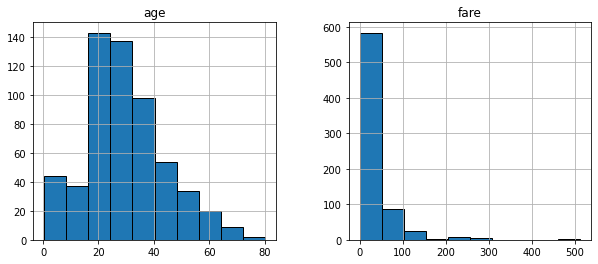

In [ ]:
train_data[["age", "fare"]].hist(figsize=(10,4), edgecolor="black");

> Ages of passengers were concentrated between 20 and 40. That is to say most of passengers aboard were adult. 

> When we look at the "fare" histogram, we can actually say that:
* fare of the third class was between 0 and 50,
* fare of the second class was between 50 and 100,
* fare of the first class was between 100 and 150.
* other values are probably outliers.

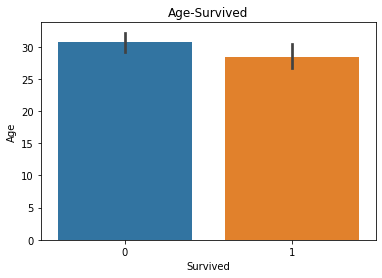

In [ ]:
sns.barplot(data=train_data, x="survived", y="age");
plt.xlabel("Survived")
plt.ylabel("Age")
plt.title("Age-Survived")
plt.show()

The figure above shows us there is a little bit difference in average ages of passengers who were dead and survived. Let's make it clearer by visualizing the age of passenger on grouping.

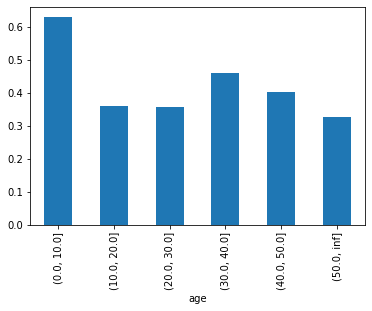

In [ ]:
train_data["survived"].groupby(pd.cut(train_data["age"], [0, 10, 20, 30, 40, 50, np.inf])).mean().plot(kind="bar");

The figure above shows the survival possibility of passengers at certain intervals. According to the figure;
* Passengers who were between 0-10 years old had the most possibility to survive, but those who were between 10-30 had the worst.
* Survival possibility of passengers who were bigger than 30 years old increased, but starting decreasing at 10 years intervals. 
>
We may say that young passengers may have given the priority to the younger and the older passengers to be alive who may be their children or siblings or parents.

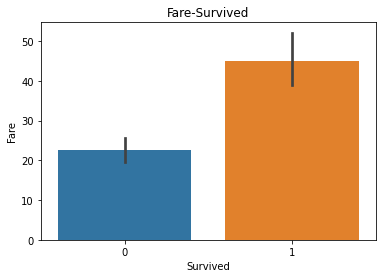

In [ ]:
sns.barplot(data=train_data, x="survived", y="fare");
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.title("Fare-Survived")
plt.show()

Let's make it clearer by visualizing the ticket prices on grouping periodically

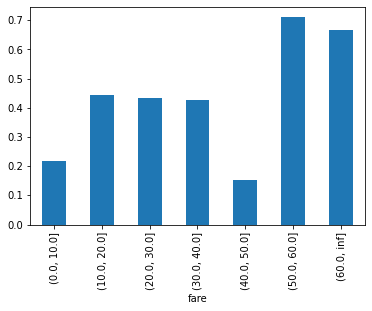

In [ ]:
train_data["survived"].groupby(pd.cut(train_data["fare"], [0, 10, 20, 30, 40, 50, 60, np.inf])).mean().plot(kind="bar");

It is understood that; 
* Passengers who paid more money for ticket had more chance for survival. The analysis unfortunately shows us again, the life always smiles at riches rather than a poor person :(
* However, passengers who bought tickets between 40-50 had the worst survival possibility. Their classes may be second or third, but this may be because of young passengers who gave the priority to the youngers and olders as mentioned above.

## Visualizing MultiFeatures upon Survived

**Pclass - Fare - Survived**

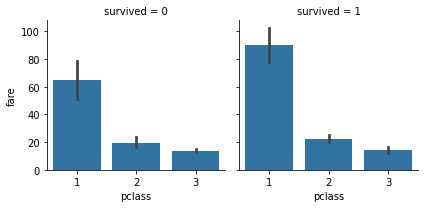

--------------------------------


pclass,1,2,3
survived,,,
0,64.552397,19.678873,13.855241
1,89.829129,22.267164,14.164542


In [ ]:
graph = sns.FacetGrid(train_data, col="survived")
graph.map(sns.barplot, "pclass", "fare")
plt.show()

print("-"*32)

fare_pclass_surv = pd.pivot_table(train_data, values="fare", index="survived", columns="pclass")
fare_pclass_surv

Like it is diagnosed above, there is negative correlation between the values of pclass and fare, for survival.
* First class which was the passengers had more survival possibility was the most expensive class. The more money passengers pay, The more chance they have to be alive.
* Second class had middle level ticket price and the passengers who bought tickets in this class had limited chance to survive
* Third class which was passengers had the worst survival possibility was the cheapest class. The less money passengers pay, The less chance they have to be alive.

**Sex - Fare - Survived**

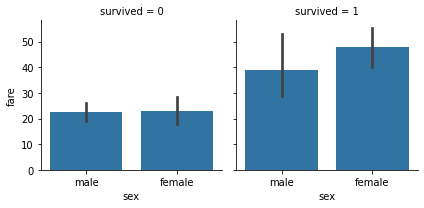

--------------------------------


sex,female,male
survived,,
0,22.799331,22.447618
1,47.959767,38.892093


In [ ]:
graph = sns.FacetGrid(train_data, col="survived")
graph.map(sns.barplot, "sex", "fare")
plt.show()

print("-"*32)

fare_sex_surv = pd.pivot_table(train_data, values="fare", index="survived", columns="sex")
fare_sex_surv

The figure above gives us informations about:
* Passengers who paid approximately 23 generally died in regardless of their sexes.  
* Male passengers who kept alive paid approximately 39. Female passengers who kept alive paid approximately 48. We can say by looking at this table that sex for those who paid less was not an important factor to be alive but was important for those who paid more.

**Embarked - Fare - Survived**

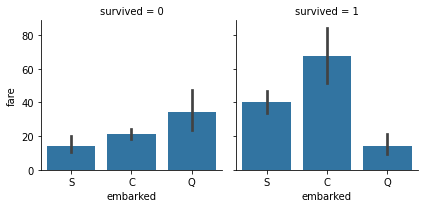

--------------------------------


embarked,C,Q,S
survived,,,
0,34.559100,14.329392,21.250847
1,67.591322,14.011542,40.090536


In [ ]:
graph = sns.FacetGrid(train_data, col="survived")
graph.map(sns.barplot, "embarked", "fare")
plt.show()

print("-"*32)

embarked_fare_surv = pd.pivot_table(train_data, values="fare", index="survived", columns="embarked")
embarked_fare_surv

Passengers, embarked from Queenstown Port, who were dead and survived generally paid about 14 fare
>

Passengers, embarked from Southampton Port;
* who paid about 21 fare generally were dead
* who paid about 40 fare survived
>

Passengers, embarked from Cherbourg Port;
* who paid about 35 fare generally were dead
* who paid about 68 fare survived

**Pclass - Age - Survived**

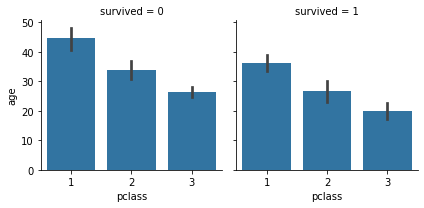

--------------------------------


pclass,1,2,3
survived,,,
0,44.518182,33.869231,26.360987
1,36.270000,26.552031,20.052267


In [ ]:
graph = sns.FacetGrid(train_data, col="survived")
graph.map(sns.barplot, "pclass", "age")
plt.show()

print("-"*32)

age_pclass_surv = pd.pivot_table(train_data, values="age", index="survived", columns="pclass")
age_pclass_surv

* First class passengers who were dead were averagely 45 years old and had less chance to survive than younger.
* Second class passengers who were dead were averagely 34 years old and had less chance to survive than younger.
* Third class passengers who were dead were averagely 26 years old and had less chance to survive than younger.

**Sex - Age - Survived**

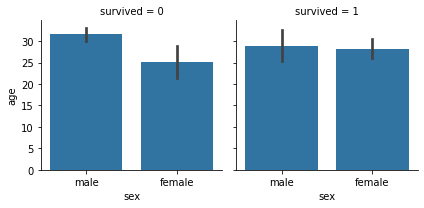

--------------------------------


sex,female,male
survived,,
0,25.234043,31.562500
1,28.222930,28.899615


In [ ]:
graph = sns.FacetGrid(train_data, col="survived")
graph.map(sns.barplot, "sex", "age")
plt.show()

print("-"*32)

age_sex_surv = pd.pivot_table(train_data, values="age", index="survived", columns="sex")
age_sex_surv

* Female passengers who were dead were average 25 years old and had less chance to survive than older females.
* Male passenger who were dead were average 31 years old and had less chance to survive than who is younger.
* Generally, the average age of passengers who were survived is about 29 in regardless of their sexes.

**Embarked - Age - Survived**

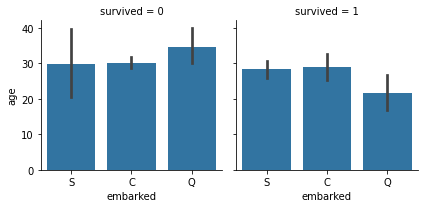

--------------------------------


embarked,C,Q,S
survived,,,
0,34.712500,29.718750,30.189895
1,28.933115,21.571429,28.298485


In [ ]:
graph = sns.FacetGrid(train_data, col="survived")
graph.map(sns.barplot, "embarked", "age")
plt.show()

print("-"*32)

embarked_age_surv = pd.pivot_table(train_data, values="age", index="survived", columns="embarked")
embarked_age_surv

Passengers, who embarked from Cherbourg Port and who were dead, were averagely 35 years old and had less chance to survive than the youngers.
>
Passengers, who embarked from Queenstown Port and who were dead, were averagely 30 years old and had less chance to survive than the youngers.
>
Passengers, who embarked from Southampton Port and who were dead, were averagely 30 years old and had a bit less chance to survive than the youngers.

## Correlations

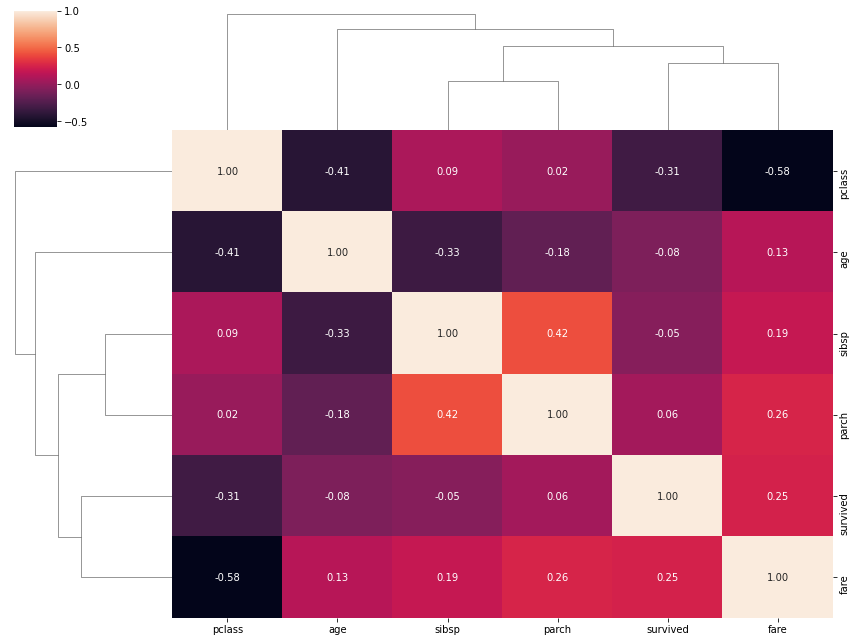

In [ ]:
corr_ = train_data.corr()

sns.clustermap(corr_, annot=True, fmt=".2f", figsize=(12,9));

We can see some dendograms and a table showing correlation rates of each variables another in clustermap.
>
Some variables have strong possitive and negative correlations with some variables, like we mentioned above. 
* For example "pclass" feature has a strong negative correlation with fare. We mentioned above, "pclass" has ordinal categorical features with observations 1,2,3. The smaller class number is, the more expensive fare is. It has already strong negative corelation with the "survived" and the "age" variables. That means a passenger, bought a ticket for first class by paying more, was generally old and had more survival possibility. But as the class number increases (from 1 to 3), the fare gets cheaper, the ages of passengers and the survival possibility decreases.
* We can see another example in SibSp and Parch features. They have correlations in the same direction with others, but have only a bit difference. We can create a new column named "family_size" including of sums the values of SibSp and Parch features and +1 (passenger himself). We are able to say if the family size increases, the fare and the class numbers increase too, but survival rate decreases
* We can also see in the clustermap that the "survived" variable has an important positive correlation with the "fare" feature  at the rate of about +25% and a strong negative correlation with the "pclass" feature at the rate of -%31.

#Replacing Missing Values

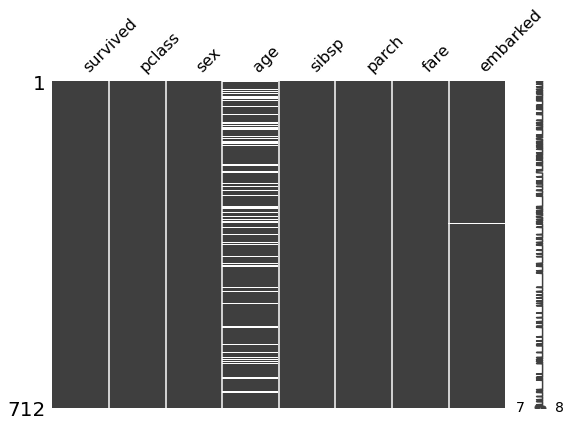

In [ ]:
msno.matrix(train_data, figsize=(9,6));

Indices of missing values in the dataset are shown above as the matrix.

As we observed in the "Loading and Understanding the Dataset", there are missing values in "age" (with 134 observations) and "embarked" (with 2 observations) features.
>
There are 2 ways mostly used to overcome the missing value problem.
* Remove all rows which have missing data from data. But our current data is not appropriate for this way. Because the number of the observations are so limited and it leads to data loss if some deleted.
* Filling them with reasonable values. This will be good choose for our problem.

Firstly lets start with "embarked" feature

## Missing Values of the "embarked" Feature

In [ ]:
train_data[train_data["embarked"].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked
61,1,1,female,38.0,0,0,80.0,NaN
829,1,1,female,62.0,0,0,80.0,NaN


We need to analyse which variables are related with missing value rows in the "embarked" features.
>
There are ties of the missing values with those;
* Passengers who survived,
* First class passengers,
* 80 fare,
* Female passengers,
* Family size = 0 (excluding passenger himself) 

Let's observe a reasonable port by visualizing "embarked" feature with the others on barplot.

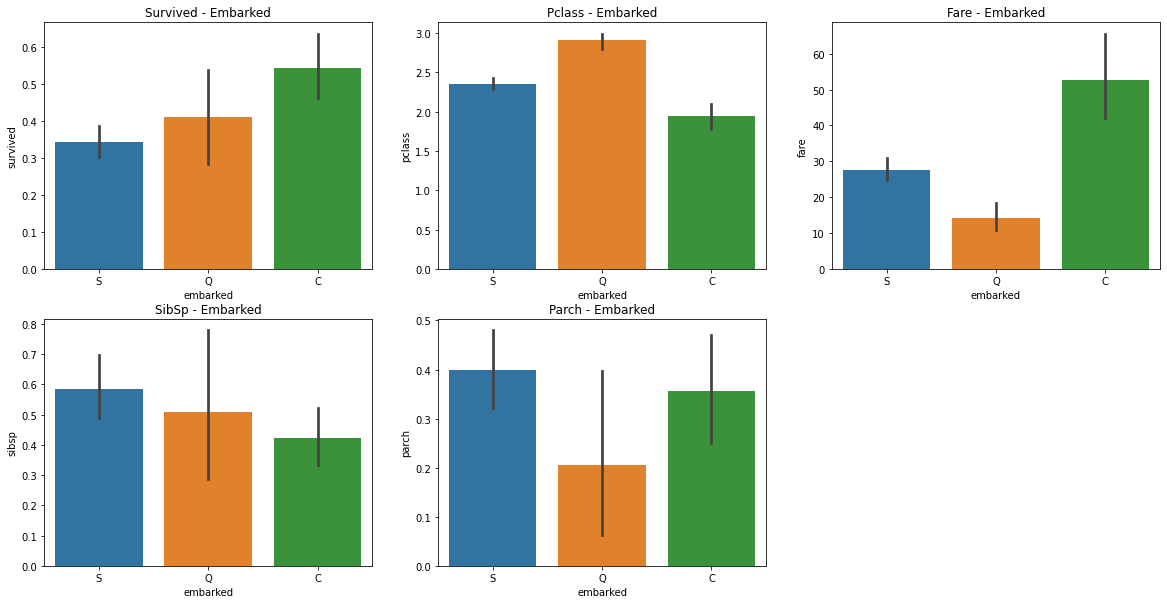

In [ ]:
plt.figure(figsize=(20,10))

plt.subplot(2,3,1)
sns.barplot(data = train_data, x="embarked", y="survived")
plt.title("Survived - Embarked")

plt.subplot(2,3,2)
sns.barplot(data = train_data, x="embarked", y="pclass")
plt.title("Pclass - Embarked")

plt.subplot(2,3,3)
sns.barplot(data = train_data, x="embarked", y="fare")
plt.title("Fare - Embarked")

plt.subplot(2,3,4)
sns.barplot(data = train_data, x="embarked", y="sibsp")
plt.title("SibSp - Embarked")

plt.subplot(2,3,5)
sns.barplot(data = train_data, x="embarked", y="parch")
plt.title("Parch - Embarked");

We are looking for a reasonable port according to the ties, we mentioned above;
* For "survived" = 1: Most of passengers, who survived, embarked from Cherbourg Port.
* For "pclass" = 1: Generally, passengers, who were in first class, embarked from Cherbourg Port.
* For "fare" = 80: Most of passengers, who paid 80 for tickets, embarked from Cherbourg Port. 
* For "sibsp" = 0: Cherbourg Port, which passengers who had no siblings and spouses embarked, is the closest port to 0
* For "parch" = 0: Queenstown Port which passengers who had no parents and children embarked is the closest port to 0

We actually have found which port should be in the missing values of the "embarked" feature in the analysis above: Cherbourg Port. Four variables say it's Cherbourg Port, only "parch" feature says it is Queenstown Port. We will now fill the missing values as "C" according to democratical methods.

In [ ]:
train_data["embarked"].fillna("C", inplace=True)

Done.

## Missing Values of the "age" Feature

In [ ]:
train_data[train_data["age"].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked
347,1,3,female,NaN,1,0,16.1000,S
629,0,3,male,NaN,0,0,7.7333,Q
334,1,1,female,NaN,1,0,133.6500,S
201,0,3,male,NaN,8,2,69.5500,S
101,0,3,male,NaN,0,0,7.8958,S
...,...,...,...,...,...,...,...,...
306,1,1,female,NaN,0,0,110.8833,C
409,0,3,female,NaN,3,1,25.4667,S
76,0,3,male,NaN,0,0,7.8958,S
601,0,3,male,NaN,0,0,7.8958,S


The table above shows us the missing value rows of "age" feature.
>
It should draw your attention "survived", "pclass" and "embarked" features may have ties with the missing values.

In [ ]:
print("For SURVIVED Feature")
print(train_data["survived"][train_data["age"].isnull()].value_counts())

print("-"*32)

print("For PCLASS Feature")
print(train_data["pclass"][train_data["age"].isnull()].value_counts())

print("-"*32)

print("For EMBARKED Feature")
print(train_data["embarked"][train_data["age"].isnull()].value_counts())

For SURVIVED Feature
0    92
1    42
Name: survived, dtype: int64
--------------------------------
For PCLASS Feature
3    104
1     21
2      9
Name: pclass, dtype: int64
--------------------------------
For EMBARKED Feature
S    63
Q    40
C    31
Name: embarked, dtype: int64


In the missing value rows of "age" feature:

* Most of passengers were dead (92 observation),
* Most of classes were third class (104 observation),
* Most of passengers were embarked from Southampton Port (63 observation).

Lets fill the missing values with median age value by filtering according to the information above

In [ ]:
median_age_val = float(round(train_data["age"][train_data["survived"]==0][train_data["pclass"] == 3][train_data["embarked"] == "S"].median()))

print("Mean age value according to the filter is", median_age_val)

Mean age value according to the filter is 24.0


In [ ]:
train_data["age"].fillna(median_age_val, inplace=True)

Now, all the missing values in the "age" feature have been filled with 24.0

In [ ]:
train_data.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Finally, the train dataset has no any missing value.
>
Let get to outlier process.

#Outlier Detection

ML models work better with a dataset which has no no any outlier. As we mentined above, it seems the train dataset has some outlier values. We need to cleanse the outlier values from tha dataset.

We will detect outliers of the features which are not categorical:
* "age",
* "sibsp"
* "parch"
* "fare"

Firstly, we will build a function, visualizing the features of the dataset by boxplot to show outliers, and giving more detailed informations.

In [ ]:
outlier_columns = ["age", "sibsp", "parch", "fare"]

def outlier_process(data, feature, type="reporting"):
  
  Q1 = data[feature].quantile(0.25)
  Q3 = data[feature].quantile(0.75)
  IQR = Q3 - Q1

  low_outlier_gate = Q1 - IQR*1.5
  upp_outlier_gate = Q3 + IQR*1.5
  outlier_number = len(data[feature][data[feature] < low_outlier_gate]) + len(data[feature][data[feature] > upp_outlier_gate])

  if type == "visualizing":
    sns.boxplot(data=data, x=feature)
    plt.title(feature.upper())
    plt.show() 

    print("As we can see in the figure above;")
    print(f"Lower outlier gate of '{feature.upper()}' feature:", round(low_outlier_gate,2))
    print(f"Median value of '{feature.upper()}' feature:", data[feature].median())
    print(f"Upper outlier gate of '{feature.upper()}' feature:", round(upp_outlier_gate,2))
    print(f"Outlier number of '{feature.upper()}' feature:", outlier_number)
    print(f"-"*32)

  elif type == "reporting":

    if outlier_number == 0:
      print(f"'{feature.upper()}' feature has no any outlier")
      
    else:
      print(f"'{feature.upper()}' feature has some outliers:", outlier_number)

  elif type == "pressing":

    data[feature] = [low_outlier_gate if i < low_outlier_gate else upp_outlier_gate if i > upp_outlier_gate else i for i in data[feature]]

    return data

This function gets 3 parameters: 
data, feature, and type

1.   data = a dataset name.
2.   feature = a feature name of the dataset.
3.   type = the process type. 

> "type" parameter gets 3 different inputs: "visualizing", "reporting" and "pressing".

*   "visualizing" shows outliers of the feature by boxplot and gives further infomations.

*   "reporting" shows only feature has how much outlier.

*   "pressing" transforms the outlier values into low_outlier_gate or upp_outlier_gate values of its feature.

Lets start seeing outliers in all the numerical features of the train dataset by boxplot and get further infomations

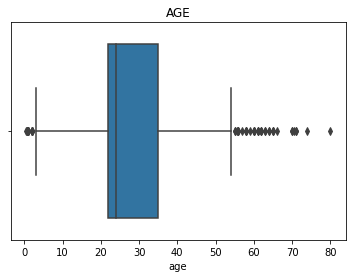

As we can see in the figure above;
Lower outlier gate of 'AGE' feature: 2.5
Median value of 'AGE' feature: 24.0
Upper outlier gate of 'AGE' feature: 54.5
Outlier number of 'AGE' feature: 55
--------------------------------


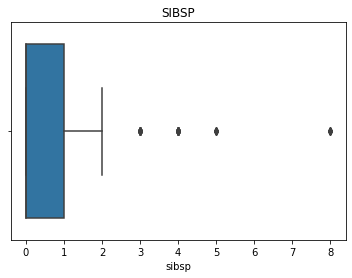

As we can see in the figure above;
Lower outlier gate of 'SIBSP' feature: -1.5
Median value of 'SIBSP' feature: 0.0
Upper outlier gate of 'SIBSP' feature: 2.5
Outlier number of 'SIBSP' feature: 39
--------------------------------


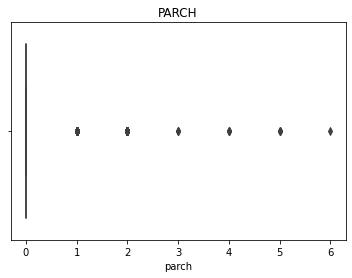

As we can see in the figure above;
Lower outlier gate of 'PARCH' feature: 0.0
Median value of 'PARCH' feature: 0.0
Upper outlier gate of 'PARCH' feature: 0.0
Outlier number of 'PARCH' feature: 169
--------------------------------


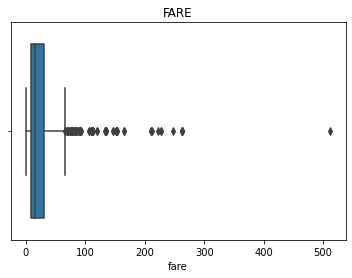

As we can see in the figure above;
Lower outlier gate of 'FARE' feature: -27.17
Median value of 'FARE' feature: 14.45625
Upper outlier gate of 'FARE' feature: 66.34
Outlier number of 'FARE' feature: 93
--------------------------------


In [ ]:
for feature in outlier_columns:
  outlier_process(train_data, feature, "visualizing")

We have called the outlier_process() function with "type = 'visualizing'" parameter by using a for loop.
>
The boxplot figures above give us some informations about which features have outlier and how much in the train dataset. To make the informations clearer, those features in the train dataset include outlier:

* 'AGE': 55
* 'SIBSP': 39
* 'PARCH': 169
* 'FARE': 93

There are generally 3 ways to overcome the outlier values;

1. Replace the outlier values with median or mean value of its variable
2. Pressing the outlier values into the low_outlier_gate or upp_outlier_gate value of its variable (This is my favourite method).
  * low_outlier_gate value if less than low_outlier_gate value
  * upp_outlier_gate value if higher than upp_outlier_gate value
3. Dropping the outlier values together with rows they are in.

We will use the SECOND way. Because;

*   The FIRST way replacing with median and mean value leads to some noises. 
*   The THIRD way dropping values from the data leads to data loss.
*   However, the SECOND way leads to less noisy and data loss

Now, we will call the outlier_process() again, but now with 'type="pressing"' parameter to change the outlier values by using a for loop.

In [ ]:
for feature in outlier_columns:
  train_data = outlier_process(train_data, feature, "pressing")

We have called outlier_process() function with a for loop to change all the outliers at the same time. The for loop pressed all the outlier values into low_outlier_gate or upp_outlier_gate of its feature.

Lets get a report of only the outlier numbers with their features in the dataset by calling the function with "type = 'reporting'" parameter

In [ ]:
for feature in outlier_columns:
  outlier_process(train_data, feature, "reporting")

'AGE' feature has no any outlier
'SIBSP' feature has no any outlier
'PARCH' feature has no any outlier
'FARE' feature has no any outlier


No any outlier

# Preparing Train Dataset for Modelling

**Creating a Column Named "family_size"**

As we mentioned in "Exploratory Data Analysis" title, we'd better create a column, named "family_size" including of sums of total numbers of siblings, spouses, parents and children of each passengers. Also, 1 should be added to the sum because of the passenger himsef/herself.

In [ ]:
def to_family_size(data):

  data["family_size"] = data["sibsp"] + data["parch"] + 1

  data.drop(["sibsp", "parch"], axis=1, inplace=True)

  return data

train_data = to_family_size(train_data)

How the dataset looks now;

In [ ]:
train_data.head()

,survived,pclass,sex,age,fare,embarked,family_size
788,1,3,male,2.5,20.5750,S,2.0
347,1,3,female,24.0,16.1000,S,2.0
629,0,3,male,24.0,7.7333,Q,1.0
734,0,2,male,23.0,13.0000,S,1.0
106,1,3,female,21.0,7.6500,S,1.0


In [ ]:
outlier_process(train_data, "family_size", "reporting")

'FAMILY_SIZE' feature has no any outlier


**Transforming the Categorical Features to Binary**

Now, lets make one-hot encoding by OneHotEncoder. The function leads to categorical values to be represented as binary. Why we do that? Because, ML models are so good when observations are 0 or 1.

Features we will make one hot encoding are;
* "pclass"
* "sex"
* "embarked"

In [ ]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_encoder(data, feature):
  ohe = OneHotEncoder(handle_unknown="ignore")
  dummied = ohe.fit_transform(data[[feature]]).toarray().astype("int64")

  data[ohe.categories_[0]] = dummied

  return data.drop(feature, axis=1)

train_data = one_hot_encoder(train_data, "sex")
train_data = one_hot_encoder(train_data, "pclass")
train_data = one_hot_encoder(train_data, "embarked")

Lets see the updated dataset

In [ ]:
train_data.head()

,survived,age,fare,family_size,female,male,1,2,3,C,Q,S
788,1,2.5,20.5750,2.0,0,1,0,0,1,0,0,1
347,1,24.0,16.1000,2.0,1,0,0,0,1,0,0,1
629,0,24.0,7.7333,1.0,0,1,0,0,1,0,1,0
734,0,23.0,13.0000,1.0,0,1,0,1,0,0,0,1
106,1,21.0,7.6500,1.0,1,0,0,0,1,0,0,1


It's done

**Splitting the Dataset**

In [ ]:
X_train = train_data.drop(["survived"], axis=1).values
y_train = train_data.survived.values.reshape(-1,1)

We have split the train dataset as X_train, which has dependent features (as known as datas), and as y_train, which has only target feature (as known as labels). We will input datas to ML models and wait for the models predict labels correct.

**Making Pipeline**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
                     ("imputer", SimpleImputer(strategy="mean")),
                     ("scaler", MinMaxScaler(feature_range=(0,1)))
                    ]).fit(X_train)

X_train = pipeline.transform(X_train) 

We have imported Pipeline to use several libraries together. What we did in the code above;
* We have imported SimpleImputer to fill missing values with features's mean values. However, there was no any missing value in train dataset, then why we have imported it? It is because of the test dataset. We created test dataset to test our ML models. The dataset may have missing value. ML models cannot work with missing values. When we call this pipeline variable for test dataset, it's missing values wil be filled with features's mean values, if any
* We have secondly imported MinMaxScaler. Train and test datasets have numerical features (especially continuous feature). Some observations (for example, "fare"s observations") will be dominant on other observations due to numerical quantity. It may lead to ML models not to be trained and predict well. Which is why, we have imported MinMaxScaler with feature_range=(0,1) parameter, which transforms values from 0 to 1 according to their quantities.

# Modelling

## Importing Models and Evaluation Metrics, Building a Class for the Process

Importing some **Classifier Models** and **Evaluation Metrics**

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

In [ ]:
from sklearn.model_selection import learning_curve, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report

In [ ]:
models_list = []

models_list.append(LogisticRegression(random_state=42))
models_list.append(SGDClassifier(random_state=42))
models_list.append(KNeighborsClassifier())
models_list.append(GaussianNB())
models_list.append(SVC(random_state=42))
models_list.append(LinearSVC(random_state=42))
models_list.append(MLPClassifier(random_state=42))
models_list.append(DecisionTreeClassifier(random_state=42))
models_list.append(RandomForestClassifier(random_state=42))
models_list.append(AdaBoostClassifier(random_state=42))
models_list.append(GradientBoostingClassifier(random_state=42))
models_list.append(XGBClassifier(random_state=42))
models_list.append(LGBMClassifier(random_state=42))
models_list.append(CatBoostClassifier(random_state=42, verbose=False))

We have stored the models in a list named "models_list"

In [ ]:
class ClassificationModel():

  def __init__(self, **kwargs):
    super().__init__()
    self.kfold = KFold(n_splits=5, shuffle=True, random_state=42)

  def learningcurve(self, models_list, X_train, y_train):

    train_size = len(X_train)

    for i in range(len(models_list)):

       train_size, train_scores, val_scores = learning_curve(models_list[i],
                                                              X_train, y_train,
                                                              cv=self.kfold,
                                                              scoring="accuracy")
       train_score, val_score = np.mean(train_scores, axis=1), np.mean(val_scores, axis=1)
       
       sns.lineplot(train_size, train_score, label="Train Score")
       sns.lineplot(train_size, val_score, label="Validation Score")
       plt.legend(loc="upper right")
       plt.title(f"{models_list[i].__class__.__name__} Learning Curve")
       plt.xlabel("Train Data Size")
       plt.ylabel("Scores")
       plt.grid(True)
       print("*"*64)
       plt.show()


  def build_model(self, alg, X_train, y_train):

    model = alg.fit(X_train, y_train)
    model_names.append(alg.__class__.__name__)

    train_scores.append(accuracy_score(y_train, model.predict(X_train)))

    val_scores.append(np.mean(cross_val_score(alg,
                                              X_train, y_train,
                                              cv=self.kfold,
                                              scoring="accuracy",
                                              n_jobs=-1,
                                              verbose=1)
                              ))
    print(f"{alg.__class__.__name__} Training and Validating Process is Over.")

  
  def model_tuning(self, alg, params, X_train, y_train):

    cv_model = GridSearchCV(alg, 
                            params, 
                            cv=self.kfold,
                            scoring="accuracy",
                            n_jobs=-1,
                            verbose=2).fit(X_train, y_train)

    cv_model_names.append(alg.__class__.__name__)
    cv_train_scores.append(accuracy_score(y_train, cv_model.best_estimator_.predict(X_train)))
    best_scores.append(cv_model.best_score_) #average of r2
    best_params.append(cv_model.best_params_)

    print(f"{alg.__class__.__name__} Model Tuning Process is Over.")


We have created a class named ClassificationModel. This class has 3 function;
* "learningcurve" function shows how algorithms work with the datasets and react to it's size by visualizing
* "build_model" function trains ML models and validates their performances with 5 validation datasets. The function also provides the results to be stored with different lists
* "model_tuning" function makes model tuning and stores the results based on 5 validation datasets.

## Learning Curve

**Firstly lets call "learningcurve" function;**

****************************************************************


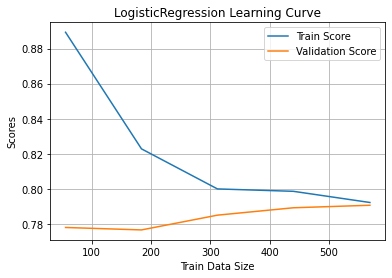

****************************************************************


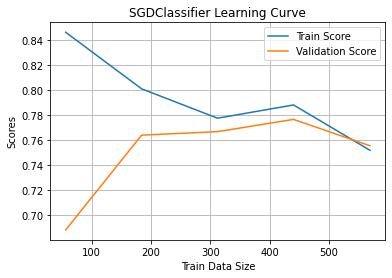

****************************************************************


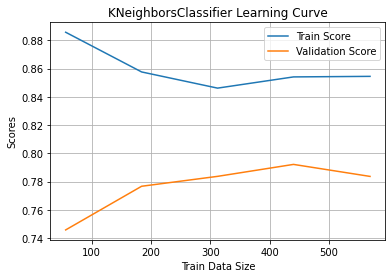

****************************************************************


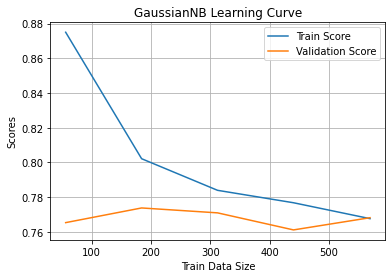

****************************************************************


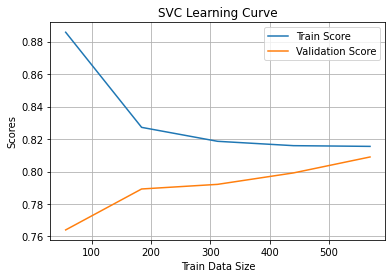

****************************************************************


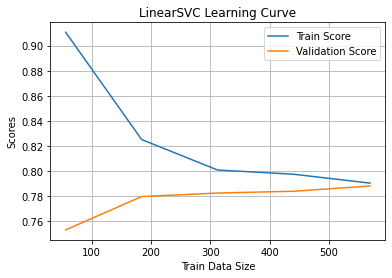

****************************************************************


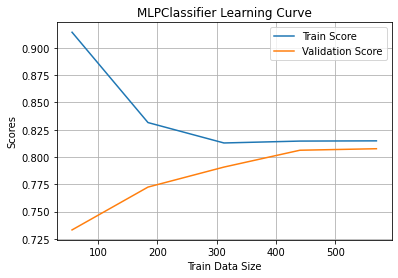

****************************************************************


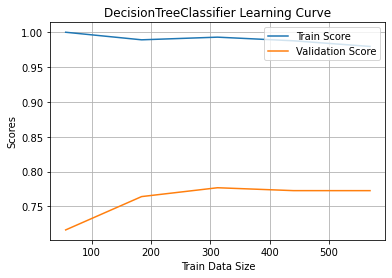

****************************************************************


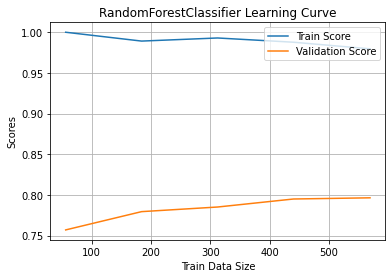

****************************************************************


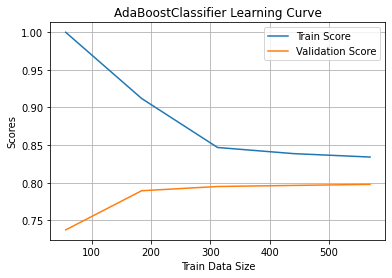

****************************************************************


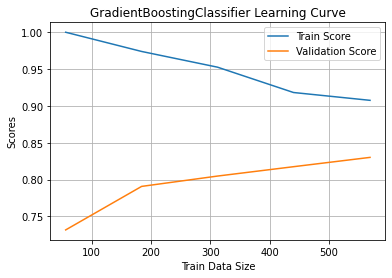

****************************************************************


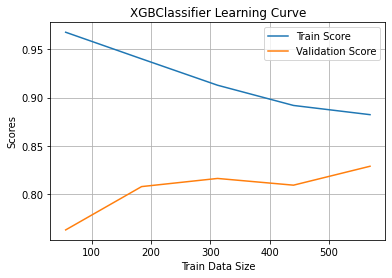

****************************************************************


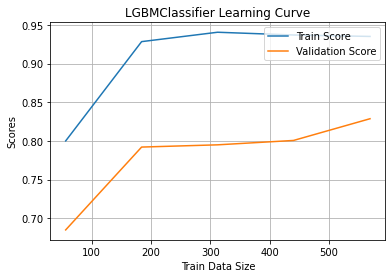

****************************************************************


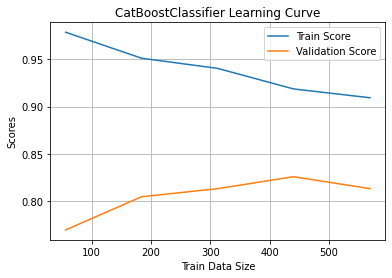

In [ ]:
clf = ClassificationModel()
clf.learningcurve(models_list, X_train, y_train)

We can observe overfitting and underfitting in some models according to the train size;

>

We can understand in the figures above that there is no underfitting in any models. But we cannot say the same thing for overfitting. For example, DecisionTreeClassifier has overfitting on the dataset (about %100 train score and %77 validation score). RandomForestClasiffier has almost the same output. However, there are some models which are able to be trained well and giving good results like SVC, MLPClassifier and XGBClassifier.

## Modelling

Now, lets see the results on a table to analyse better after storing the results by calling "build_model" function.

In [ ]:
model_names = []
train_scores = []
val_scores = []

for model in models_list:
  clf = ClassificationModel()
  clf.build_model(model, X_train, y_train)

In [ ]:
model_dataset = pd.DataFrame({"Models": model_names,
                              "Train_Scores": train_scores,
                              "Val_Average_Scores": val_scores}).sort_values(by="Val_Average_Scores", ascending=False)
model_dataset

,Models,Train_Scores,Val_Average_Scores
11,XGBClassifier,0.863764,0.830070
12,LGBMClassifier,0.935393,0.825864
10,GradientBoostingClassifier,0.898876,0.820240
13,CatBoostClassifier,0.907303,0.818822
6,MLPClassifier,0.811798,0.810361
4,SVC,0.816011,0.808943
9,AdaBoostClassifier,0.827247,0.800561
8,RandomForestClassifier,0.976124,0.796435
0,LogisticRegression,0.794944,0.787876
5,LinearSVC,0.789326,0.787866


We will select only first three models for model tunning, and after that we will touch the test dataset.
* ***XGBClassifier*** has %86.37 train score and %83.00 validation score. There is a little bit overfitting. It's scores are good comparing with other models in regard to overfiting.
* ***LGBMClassifier*** has %93.53 train and %82.58 validation score. It has overfitting more than XGBClassifier model.
* ***GradientBoostingClassifier*** has %89.88 train score and %82.02 validation score. It has overfitting, too.

>
Lets see how the models above will react to model tunning. After the model tunning, we will run with only 1 model which gives the best performance.

## Model Tuning

In [ ]:
#Model List
cv_models_list = []

cv_models_list.append(XGBClassifier(random_state=42))
cv_models_list.append(LGBMClassifier(random_state=42))
cv_models_list.append(GradientBoostingClassifier(random_state=42))

#Model Parameters
xgb_params = {"n_estimators": [50, 100, 200, 500, 1000],
              "max_depth": np.arange(2,10,2),
              "learning_rate": [1e-4, 1e-3, 1e-2, 1e-1, 1],
              "gamma": [1e-3, 1e-2, 1e-1, 1, 10],
              "n_jobs":[-1]}

lgbm_params = {"n_estimators": [50, 100, 200, 500, 1000],
              "max_depth": np.arange(2,10,2),
              "learning_rate": [1e-4, 1e-3, 1e-2, 1e-1, 1],
              "n_jobs":[-1]}

gbm_params = {"n_estimators": [50, 100, 200, 500, 1000],
              "max_depth": np.arange(2,10,2),
              "learning_rate": [1e-4, 1e-3, 1e-2, 1e-1, 1],
              "min_samples_split": [10, 30, 50, 100]}
params_list = [xgb_params, lgbm_params, gbm_params]

* A list named cv_models_list will store the models (XGBClassifier, LGBMClassifier and GradientBoostingClassifier) for model tunning.
* A list named params_list will store the parameters of the models to be used in model tunning process.

In [ ]:
cv_model_names = []
cv_train_scores = []
best_scores = []
best_params = []

for i in range(len(cv_models_list)):
  clf = ClassificationModel()
  clf.model_tuning(cv_models_list[i], params_list[i], X_train, y_train)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
XGBClassifier Model Tuning Process is Over.
Fitting 5 folds for each of 100 candidates, totalling 500 fits
LGBMClassifier Model Tuning Process is Over.
Fitting 5 folds for each of 400 candidates, totalling 2000 fits
GradientBoostingClassifier Model Tuning Process is Over.


We have run the process by using a for loop. The results have been stored. Lets check the results on a DataFrame.

In [ ]:
cv_dataframe = pd.DataFrame({"Cv_Models": cv_model_names,
                             "Cv_Train_Scores": cv_train_scores,
                             "Cv_Val_Averages": best_scores,
                             "Best_Params": best_params})
cv_dataframe

,Cv_Models,Cv_Train_Scores,Cv_Val_Averages,Best_Params
0,XGBClassifier,0.905899,0.837122,"{'gamma': 1, 'learning_rate': 1, 'max_depth': ..."
1,LGBMClassifier,0.877809,0.837142,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti..."
2,GradientBoostingClassifier,0.912921,0.838521,"{'learning_rate': 0.01, 'max_depth': 6, 'min_s..."


Comparing to the results of all the models which were trained with their default parameters, the validation results of the models after the model tunning process (except XGBClassifier model) is a little bit better. 
* ***XGBClassifier*** model after the model tunning process has had a bit more overfitting although the validation score increased a bit: %90.58 training score and %83.71 (before tuning the train score was %86.37 and the validation score %83.00).
* ***LGBMClassifier*** model after the model tunning process decreased overfitting, but still exists: %87.78 training score and %83.71 validation score (before tuning, it was %93.53 train score and %82.58 validation score). But again, the model has been improved.
* ***GradientBoostingClassifier*** model after the model tunning process has had a bit more overfitting although the validation score increased a bit: %91.29 training score and %83.85 (before tuning it was %89.88 train score and %82.02 validation score)

>
We can exert effort a bit more. You can try...
>
Finally, XGBClassifier has been selected for our problem.

# Time to Touch Test Dataset

It's time to see the tunned XGBClassifier model's performans on test dataset which has not been seen so far by model.
>
We need to firstly tranform the test dataset like what we did for train_dataset in "Preparing Train Dataset for Modelling" title.
>
Lets start..

In [ ]:
# merging sibsp and parch as family_size
test_data = to_family_size(test_data)

# one hot encoding
test_data = one_hot_encoder(test_data, "sex")
test_data = one_hot_encoder(test_data, "pclass")
test_data = one_hot_encoder(test_data, "embarked")

# splitting the dataset as X_test including datas and as y_test including labels
X_test = test_data.drop(["survived"], axis=1).values
y_test = test_data.survived.values.reshape(-1,1)

# lets call pipeline: 1. fill missing values as mean of features which have any missing value, and 2. transform the observations from 0 to 1
X_test = pipeline.transform(X_test) 

In [ ]:
xgb_model = XGBClassifier(gamma= 1, learning_rate= 1, max_depth= 4, n_estimators= 50, n_jobs= -1, random_state=42).fit(X_train, y_train)
test_pred = xgb_model.predict(X_test)
print(f"Accuracy Score of Test Datas:", accuracy_score(y_test, test_pred))

Accuracy Score of Test Datas: 0.8715083798882681


We have tested the model's performance on the test dataset. It's accuracy score is %87.15. That is a good result. Lets see more detail.



In [ ]:
classification_report(y_test, test_pred, 
                      target_names=["Dead", "Survived"],
                      labels=[0, 1])

'              precision    recall  f1-score   support\n\n        Dead       0.88      0.92      0.90       114\n    Survived       0.85      0.78      0.82        65\n\n    accuracy                           0.87       179\n   macro avg       0.87      0.85      0.86       179\nweighted avg       0.87      0.87      0.87       179\n'

We can see some evaluation metrics on the classification report.


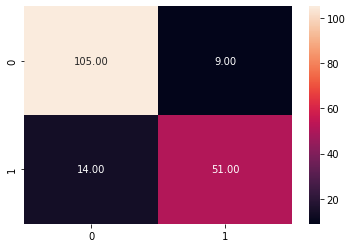

In [ ]:
cm = confusion_matrix(y_test, test_pred)

sns.heatmap(cm, annot=True, fmt=".2f");

* The model have predicted totally 156 correct and 23 false results on test data.
* 9 results have been predicted as 1, but must have been 0; and 14 results have been predicted as 0 but must have been 1.
* 51 results have been predicted 1 as correct; 105 results have been predicted 0 as correct.

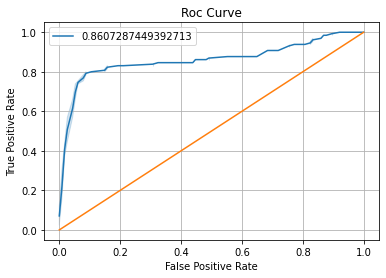

In [ ]:
fpr, tpr, threshold = roc_curve(y_test, model.predict_proba(X_test)[:,1])

auc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

sns.lineplot(fpr, tpr, label= auc_score)
sns.lineplot([0, 1], [0, 1])
plt.legend()
plt.title("Roc Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()

ROC Curve is a probability curve for different classes. ROC curve tells us how good the model is for distinguishing the given classes, in terms of the predicted probability.
Area Under Curve (AUC) score represents the degree or measure of separability.  A model with higher AUC is better at predicting True Positives and True Negatives. AUC score of our model is %86.07.

Our test dataset does not have bad result, but the result should be improved by spending more time. 
>
Let's finish our process by saving the model.

In [ ]:
xgb_model.save_model("XGBClassifier_for_Titanic.h5")

In [ ]:
imported_model = XGBClassifier().load_model("XGBClassifier_for_Titanic.h5")